In [1]:
import os, torch
import pandas as pd
import numpy as np
from pathlib import Path
from pathlib import PureWindowsPath
import matplotlib.pyplot as plt

In [2]:
errors = pd.read_csv("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_CNN8_pred_intervals.csv")
errors

,patient_id,date,true_interval,pred_interval,error
0,NKI-d23231-00-0039,2017-07-25,57.171478,48.500893,8.670586
1,NKI-d23231-00-0039,2018-11-13,57.374821,51.105110,6.269711
2,NKI-d23231-00-0039,2019-10-17,34.928001,42.091209,7.163208
3,NKI-d23231-00-0039,2021-09-07,33.767391,40.243919,6.476528
4,NKI-d23231-00-0039,2022-10-21,35.551998,29.236238,6.315760
...,...,...,...,...,...
327,NKI-d23231-00-0869,2022-05-04,29.625429,38.785759,9.160330
328,NKI-d23231-00-0878,2023-03-17,34.862000,40.242104,5.380104
329,NKI-d23231-00-0881,2021-11-05,34.751999,32.907066,1.844933
330,NKI-d23231-00-0881,2022-08-17,30.625000,27.765711,2.859289


In [3]:
paired_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/Preprocessing/Time_interval_data/paired_preprocessed_data.csv")
paired_data

,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,arterial_organs,portal_organs,arterial_timing,portal_timing,time_interval,split,output_dir,base_name_raw,dups_count,base_name,output_path,exists
0,NKI-d23231-00-0002,2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Late,Too Early,0.00519,val,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0002_2015-12-01,0,NKI-d23231-00-0002_2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
1,NKI-d23231-00-0005,2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,53.64779,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0005_2010-02-04,0,NKI-d23231-00-0005_2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
2,NKI-d23231-00-0005,2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Too Early,33.40000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0005_2012-06-18,0,NKI-d23231-00-0005_2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
3,NKI-d23231-00-0005,2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,30.84280,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0005_2022-05-11,0,NKI-d23231-00-0005_2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
4,NKI-d23231-00-0005,2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,32.75200,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0005_2022-10-17,0,NKI-d23231-00-0005_2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2002,NKI-d23231-00-0887,2023-05-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,31.57800,val,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0887_2023-05-24,0,NKI-d23231-00-0887_2023-05-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,True
2003,NKI-d23231-00-0887,2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,28.90000,val,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0887_2023-08-30,0,NKI-d23231-00-0887_2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,True
2004,NKI-d23231-00-0888,2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,31.78189,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0888_2022-04-20,0,NKI-d23231-00-0888_2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,True
2005,NKI-d23231-00-0888,2023-04-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,

In [4]:
errors = errors.merge(paired_data,
                      left_on=["patient_id","date"],
                      right_on=["SubjectKeyRadiology","ExamDate"],
                      how="inner")
errors

,patient_id,date,true_interval,pred_interval,error,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,arterial_organs,...,arterial_timing,portal_timing,time_interval,split,output_dir,base_name_raw,dups_count,base_name,output_path,exists
0,NKI-d23231-00-0039,2017-07-25,57.171478,48.500893,8.670586,NKI-d23231-00-0039,2017-07-25,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,Just Right,Just Right,57.17148,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0039_2017-07-25,0,NKI-d23231-00-0039_2017-07-25,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
1,NKI-d23231-00-0039,2018-11-13,57.374821,51.105110,6.269711,NKI-d23231-00-0039,2018-11-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,Just Right,Just Right,57.37482,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0039_2018-11-13,0,NKI-d23231-00-0039_2018-11-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
2,NKI-d23231-00-0039,2019-10-17,34.928001,42.091209,7.163208,NKI-d23231-00-0039,2019-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,Just Right,Just Right,34.92800,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0039_2019-10-17,0,NKI-d23231-00-0039_2019-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
3,NKI-d23231-00-0039,2021-09-07,33.767391,40.243919,6.476528,NKI-d23231-00-0039,2021-09-07,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,Just Right,Just Right,33.76739,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0039_2021-09-07,0,NKI-d23231-00-0039_2021-09-07,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
4,NKI-d23231-00-0039,2022-10-21,35.551998,29.236238,6.315760,NKI-d23231-00-0039,2022-10-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,Just Right,Just Right,35.55200,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0039_2022-10-21,0,NKI-d23231-00-0039_2022-10-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,NKI-d23231-00-0869,2022-05-04,29.625429,38.785759,9.160330,NKI-d23231-00-0869,2022-05-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,Just Right,Just Right,29.62543,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0869_2022-05-04,0,NKI-d23231-00-0869_2022-05-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,True
440,NKI-d23231-00-0878,2023-03-17,34.862000,40.242104,5.380104,NKI-d23231-00-0878,2023-03-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,Just Right,Just Right,34.86200,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0878_2023-03-17,0,NKI-d23231-00-0878_2023-03-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,True
441,NKI-d23231-00-0881,2021-11-05,34.751999,32.907066,1.844933,NKI-d23231-00-0881,2021-11-05,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,Just Right,Just Right,34.75200,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0881_2021-11-05,0,NKI-d23231-00-0881_2021-11-05,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,True
442,NKI-d23231-00-0881,2022-08-17,30.625000,27.765711,2.859289,NKI-d232

In [5]:
big_errors = errors[errors.error >= 10]
big_errors[["SubjectKeyRadiology","ExamDate",  "output_path", "arterial_timing","portal_timing", "time_interval", "pred_interval", "error"]]

,SubjectKeyRadiology,ExamDate,output_path,arterial_timing,portal_timing,time_interval,pred_interval,error
18,NKI-d23231-00-0053,2007-03-06,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,40.00000,51.043995,11.043995
22,NKI-d23231-00-0053,2008-02-22,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,54.73340,43.076595,34.255917
23,NKI-d23231-00-0053,2008-02-22,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,77.33251,43.076595,34.255917
55,NKI-d23231-00-0055,2013-07-05,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Too Early,18.70000,29.575979,10.875978
57,NKI-d23231-00-0057,2009-12-07,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,36.00000,44.383503,12.616497
...,...,...,...,...,...,...,...,...
418,NKI-d23231-00-0777,2019-03-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,56.78063,43.322678,13.457951
419,NKI-d23231-00-0777,2020-11-25,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,56.61176,35.546345,21.065414
421,NKI-d23231-00-0783,2018-11-27,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,72.90377,48.813923,24.089848
423,NKI-d23231-00-0783,2020-07-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,57.01445,46.094975,10.919476


In [6]:
len(big_errors)

61

/tmp/ipykernel_1775154/2703023904.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(row["output_path"], map_location="cpu")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/pairs_preprocessed/train/NKI-d23231-00-0392_2014-01-09.pt'

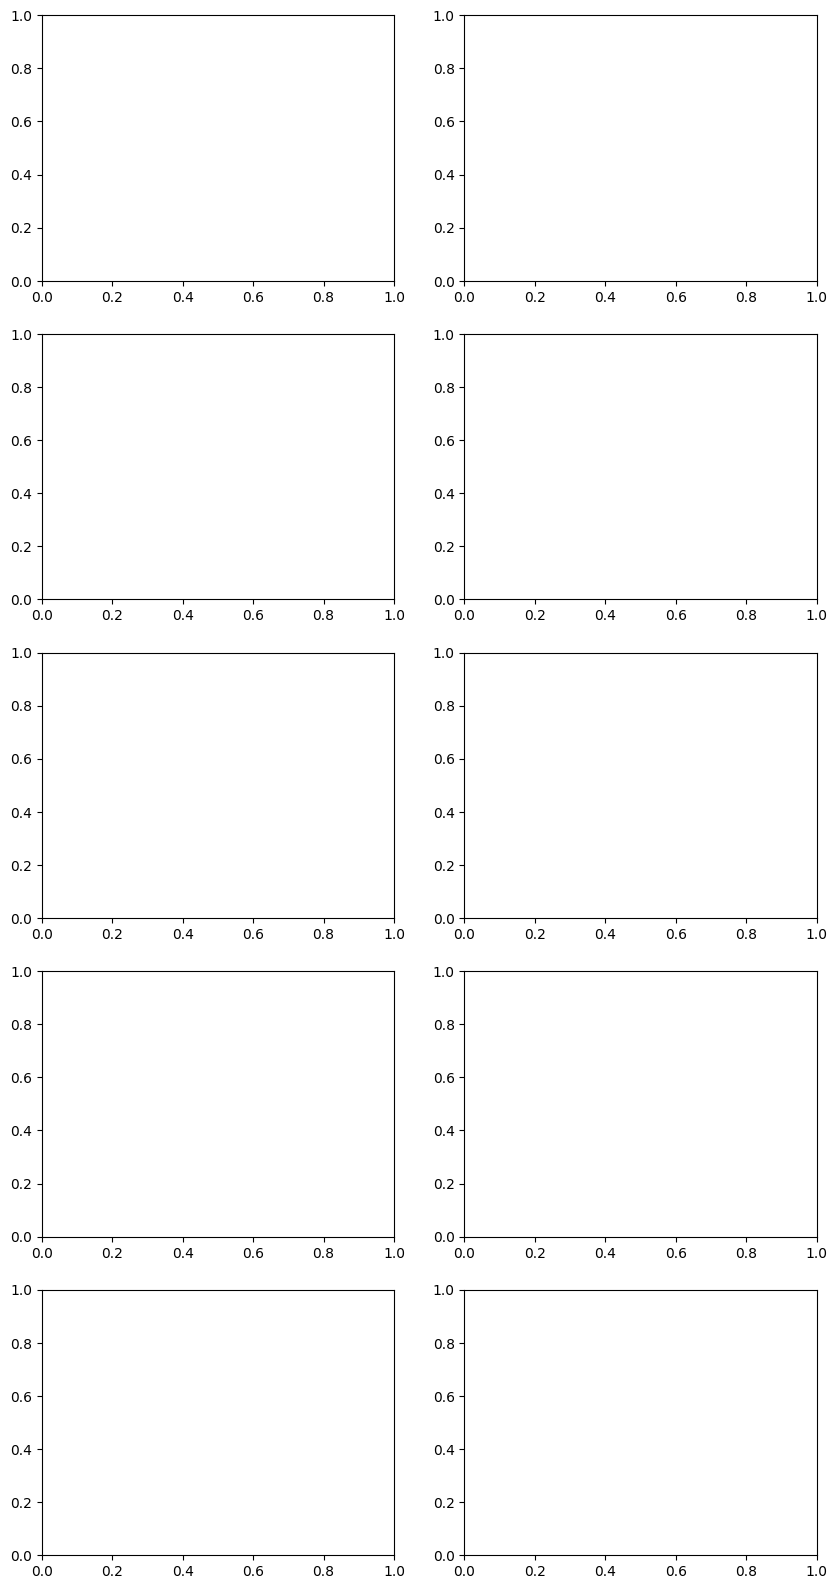

In [8]:
# sample 5 rows
df = big_errors[big_errors.arterial_timing=="Too Early"]
sample = df.sample(5, replace=False)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i, (_, row) in enumerate(sample.iterrows()):

    data = torch.load(row["output_path"], map_location="cpu")

    arterial = data["arterial_image"]
    portal = data["portal_image"]

    # assume shape [C, H, W, D] or [H, W, D]
    if arterial.ndim == 4:
        arterial_img = arterial[0]
        portal_img = portal[0]
    else:
        arterial_img = arterial
        portal_img = portal

    # take middle slice along depth
    mid_a = arterial_img.shape[-1] // 2
    mid_p = portal_img.shape[-1] // 2

    ax_a = axes[i, 0]
    ax_p = axes[i, 1]

    ax_a.imshow(np.rot90(arterial_img[:, :, 100], k=1), cmap="gray")
    ax_a.set_title(f"Arterial {row["arterial_timing"]}")
    ax_a.axis("off")

    ax_p.imshow(np.rot90(portal_img[:, :, 100], k=1), cmap="gray")
    ax_p.set_title(f"Portal {row["portal_timing"]}")
    ax_p.axis("off")

    axes[i, 0].annotate(
    f"True: {row['time_interval']:.2f}s | Pred: {row['pred_interval']:.2f}s",
    xy=(1.25, 1.15),
    xycoords="axes fraction",
    ha="center",
    fontsize=12,
    fontweight="bold")

plt.subplots_adjust(hspace=0.25, wspace=0.00001)
plt.show()